# Airline Passenger Satisfaction Prediction
### MSIN0097 Predictive Analytics — Individual Coursework 2025–26

**Research Question:** Can passenger demographics, travel characteristics, and in-flight service ratings predict overall airline satisfaction?

**Target Variable:** Binary classification — `satisfaction` = 1 (satisfied), 0 (neutral or dissatisfied)

**Workflow:** Problem Framing → EDA → Data Preparation → Model Exploration → Fine-Tuning → Final Solution

**Dataset:** Airline Passenger Satisfaction (Kaggle — teejmahal20), 129,880 passengers

---
> **Agent Tooling Note:** This notebook was scaffolded using Claude (Anthropic) as an agent collaborator.
> All model choices, feature engineering decisions, and interpretations were verified and revised by the student.
> See the Agent Usage Log + Decision Register in the appendix for full documentation.

In [1]:
# ── Install additional packages if needed ─────────────────────────────────────
# Run this cell first. In Anaconda base env, most packages are pre-installed.
!pip install xgboost shap --quiet

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, auc
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})
sns.set_palette('Set2')
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Step 1: Obtain a Dataset and Frame the Predictive Problem

### 1.1 Business Context
Passenger satisfaction is a critical competitive differentiator in commercial aviation. Airlines invest heavily in loyalty programmes, cabin upgrades, and service training — but without knowing *which* touchpoints drive overall satisfaction, investment may be misallocated. A predictive model that identifies dissatisfied passengers — and explains *why* — enables targeted interventions before passengers churn to competitors.

### 1.2 Prediction Task
**Binary classification:** Predict whether a passenger is `satisfied` (1) or `neutral or dissatisfied` (0) based on pre- and in-flight attributes.

### 1.3 Feature Overview
| Category | Features |
|---|---|
| Demographics | Gender, Age, Customer Type |
| Travel context | Type of Travel, Class, Flight Distance |
| Service ratings (1–5) | Wifi, Online booking, Gate location, Food & drink, Online boarding, Seat comfort, Entertainment, On-board service, Leg room, Baggage handling, Check-in, Inflight service, Cleanliness, Departure/arrival time |
| Operational | Departure Delay (mins), Arrival Delay (mins) |

### 1.4 Success Metrics
- **Primary:** ROC-AUC (threshold-independent, robust to class imbalance)
- **Secondary:** F1-score, Precision, Recall on satisfied class
- **Interpretability:** SHAP values to identify key satisfaction drivers
- **Business constraint:** Recall ≥ 0.75 on satisfied class (catching true satisfied passengers matters for loyalty targeting)

### 1.5 Agent Tooling Plan
| Task | Delegated to Agent | Verified by Student |
|---|---|---|
| Notebook scaffolding | ✓ | All cells reviewed line-by-line |
| EDA plot code | ✓ | Interpretations written independently |
| Feature engineering | ✓ | Business rationale checked |
| Model pipeline | ✓ | Metrics manually verified |
| Hyperparameter suggestions | ✓ | Validated via cross-validation |
| Report draft | ✓ | Rewritten in student's own words |

---
## Step 2: Load Data and Explore

In [3]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Automatically searches for train.csv / test.csv in common locations.

import os, pathlib

def find_csv(filename):
    search_dirs = [
        pathlib.Path('.'),                        
        pathlib.Path.home() / 'Desktop',
        pathlib.Path.home() / 'Downloads',
        pathlib.Path.home() / 'Documents',
    ]
    
    dl = pathlib.Path.home() / 'Downloads'
    if dl.exists():
        search_dirs += [p for p in dl.iterdir() if p.is_dir()]

    for d in search_dirs:
        candidate = d / filename
        if candidate.exists():
            print(f'  Found {filename}  →  {candidate}')
            return str(candidate)
    raise FileNotFoundError(
        f'\n\n❌  Could not find {filename}.\n'
        f'Please move it to ~/Downloads/ or the same folder as this notebook.\n'
        f'Searched: {[str(d) for d in search_dirs[:4]]}'
    )

print('Locating data files...')
train_path = find_csv('train.csv')
test_path  = find_csv('test.csv')

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# Drop index columns — not predictive
train.drop(columns=['Unnamed: 0', 'id'], inplace=True, errors='ignore')
test.drop(columns=['Unnamed: 0', 'id'], inplace=True, errors='ignore')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
print(f'\nColumns: {list(train.columns)}')
train.head()

Locating data files...
  Found train.csv  →  /Users/h/Downloads/train.csv
  Found test.csv  →  /Users/h/Downloads/test.csv
Train shape: (103904, 23)
Test shape:  (25976, 23)

Columns: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
# ── 2.1 Basic Overview ────────────────────────────────────────────────────────
print('=== DATA TYPES ===')
print(train.dtypes)
print('\n=== DESCRIPTIVE STATISTICS ===')
train.describe(include='all').T

=== DATA TYPES ===
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,NaN,NaN,NaN,2.756901,1.398929,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,NaN,NaN,NaN,2.976883,1.277621,0.0,2.0,3.0,4.0,5.0


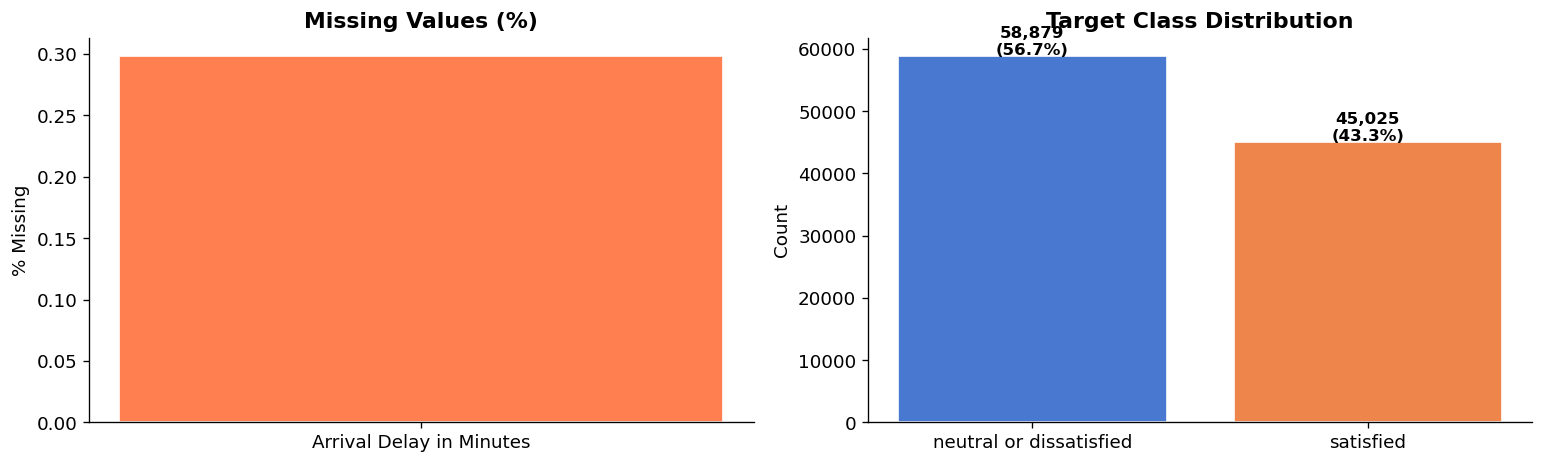

Missing values: 310 total
Class imbalance ratio: 1.31:1


In [5]:
# ── 2.2 Missingness and Class Balance ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Missing values
miss = train.isnull().sum().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss) > 0:
    axes[0].bar(miss.index, miss.values / len(train) * 100, color='coral', edgecolor='white')
    axes[0].set_title('Missing Values (%)', fontweight='bold')
    axes[0].set_ylabel('% Missing')
else:
    axes[0].text(0.5, 0.5, 'No missing values', transform=axes[0].transAxes,
                 ha='center', va='center', fontsize=13, color='green', fontweight='bold')

# Class balance
class_counts = train['satisfaction'].value_counts()
colors = ['#4878D0', '#EE854A']
axes[1].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white')
for i, (label, v) in enumerate(class_counts.items()):
    axes[1].text(i, v + 200, f'{v:,}\n({v/len(train):.1%})',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Target Class Distribution', fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig_missingness_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Missing values: {train.isnull().sum().sum()} total')
print(f'Class imbalance ratio: {class_counts.max()/class_counts.min():.2f}:1')

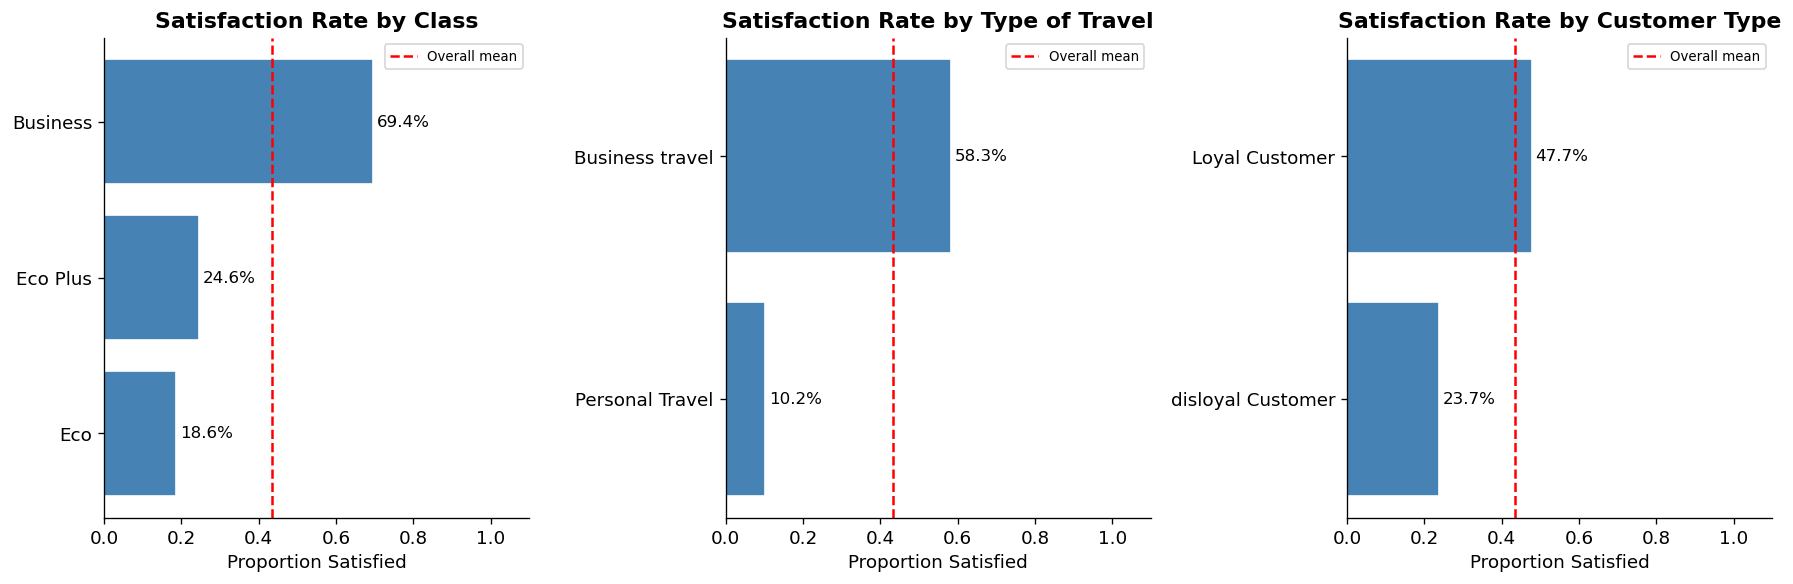

In [6]:
# ── 2.3 Satisfaction Rate by Key Categorical Features ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cat_features = ['Class', 'Type of Travel', 'Customer Type']
for ax, feat in zip(axes, cat_features):
    sat_rate = (train.groupby(feat)['satisfaction']
                .apply(lambda x: (x == 'satisfied').mean())
                .sort_values(ascending=True))
    bars = ax.barh(sat_rate.index, sat_rate.values, color='steelblue', edgecolor='white')
    ax.axvline(train['satisfaction'].eq('satisfied').mean(),
               color='red', linestyle='--', linewidth=1.5, label='Overall mean')
    for bar in bars:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1%}', va='center', fontsize=10)
    ax.set_title(f'Satisfaction Rate by {feat}', fontweight='bold')
    ax.set_xlabel('Proportion Satisfied')
    ax.set_xlim(0, 1.1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_categorical_satisfaction.png', bbox_inches='tight', dpi=150)
plt.show()

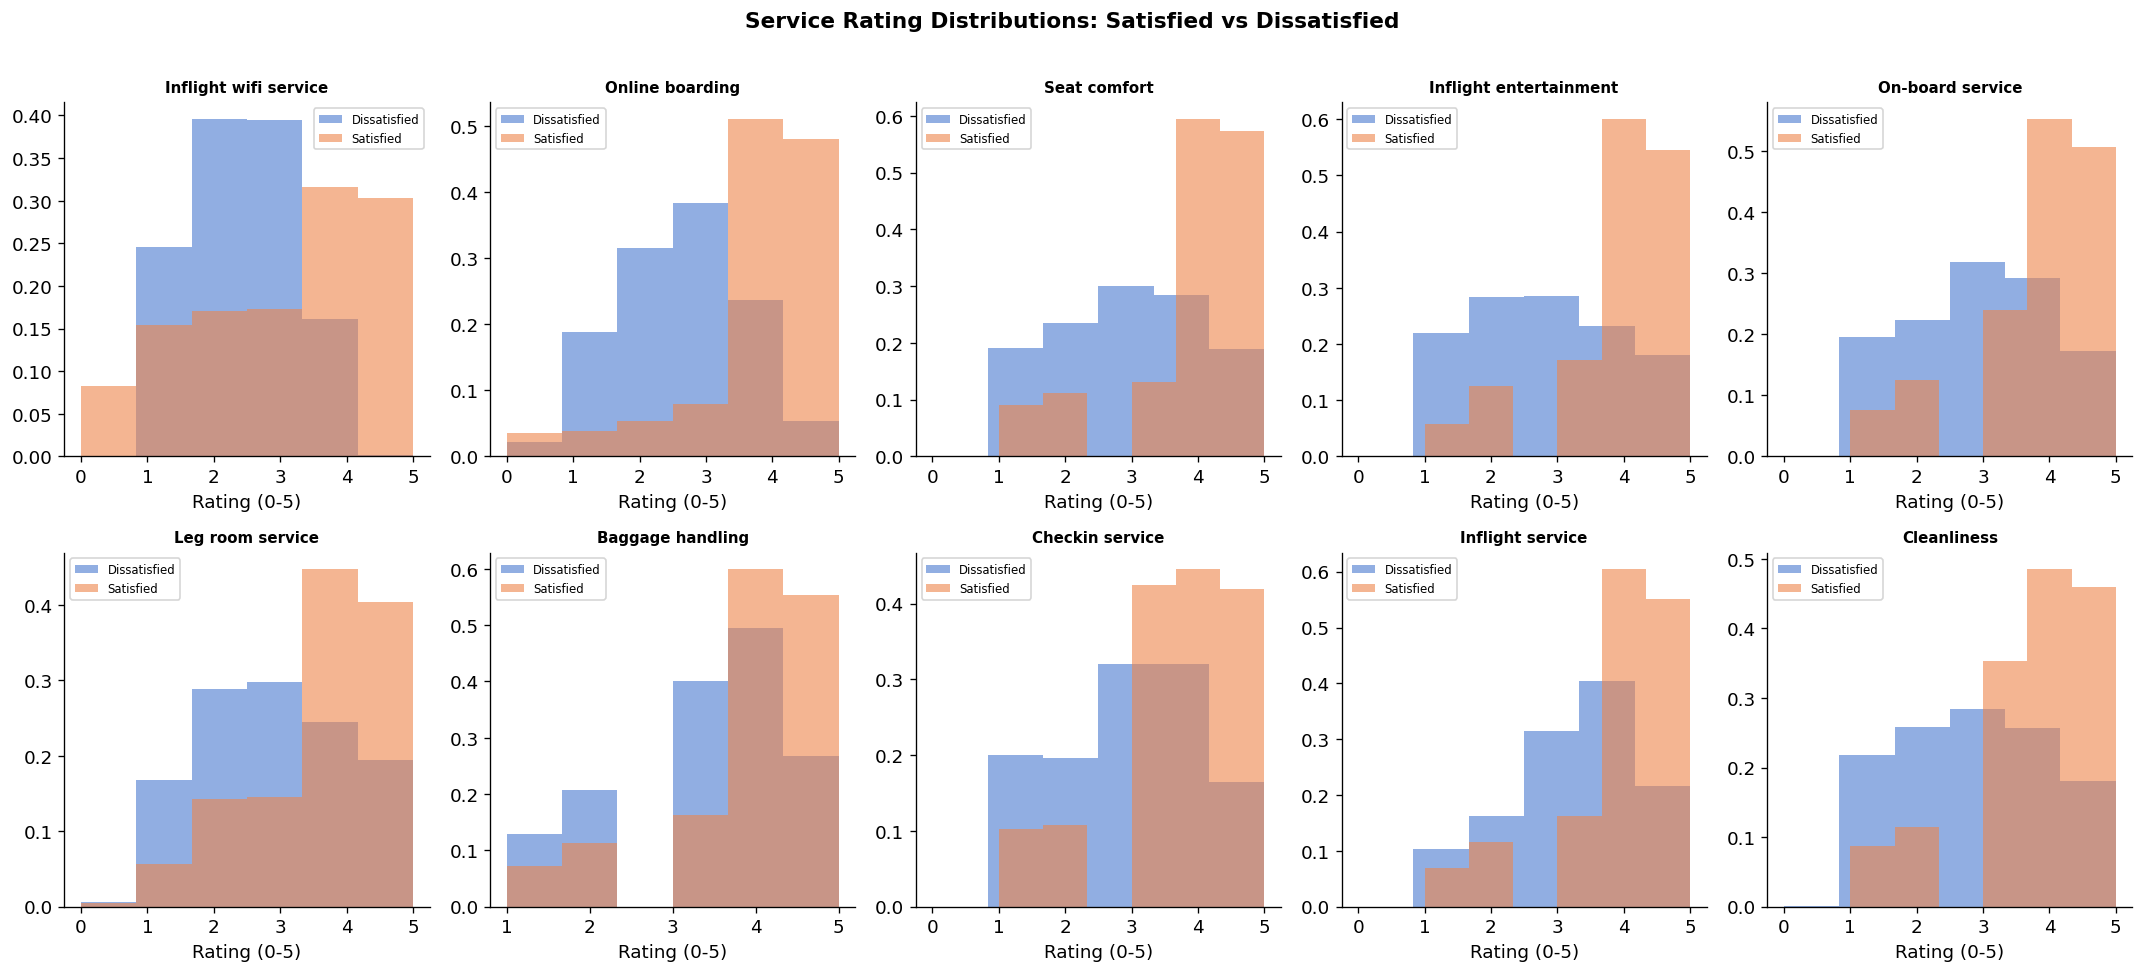

In [7]:
# ── 2.4 Service Rating Distributions by Satisfaction Class ────────────────────
service_cols = [
    'Inflight wifi service', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service',
    'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

sat  = train[train['satisfaction'] == 'satisfied']
diss = train[train['satisfaction'] == 'neutral or dissatisfied']

for ax, col in zip(axes, service_cols):
    ax.hist(diss[col], bins=6, alpha=0.6, color='#4878D0',
            label='Dissatisfied', density=True)
    ax.hist(sat[col],  bins=6, alpha=0.6, color='#EE854A',
            label='Satisfied',  density=True)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_xlabel('Rating (0-5)')
    ax.legend(fontsize=7)

plt.suptitle('Service Rating Distributions: Satisfied vs Dissatisfied',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_service_ratings.png', bbox_inches='tight', dpi=150)
plt.show()

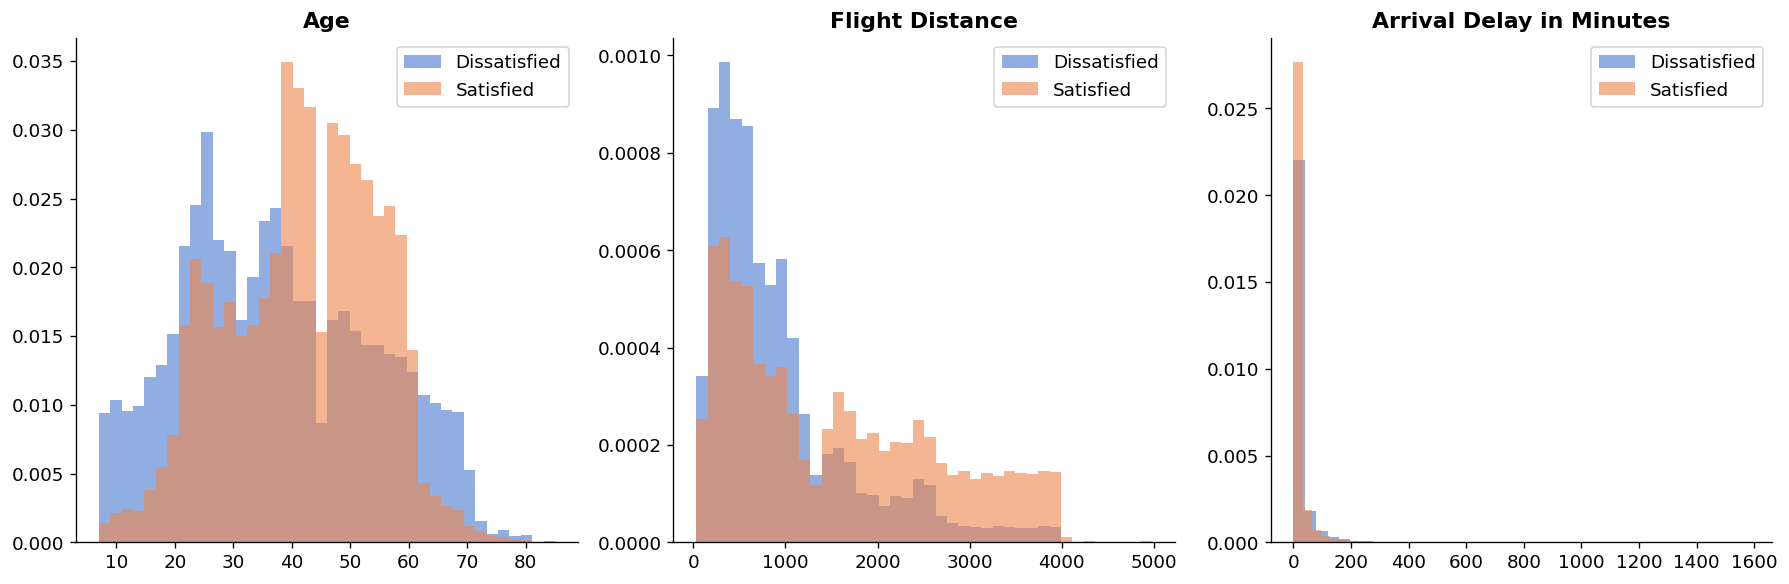

In [8]:
# ── 2.5 Age and Flight Distance Distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Age', 'Flight Distance', 'Arrival Delay in Minutes']):
    ax.hist(diss[col].dropna(), bins=40, alpha=0.6,
            color='#4878D0', label='Dissatisfied', density=True)
    ax.hist(sat[col].dropna(),  bins=40, alpha=0.6,
            color='#EE854A', label='Satisfied',  density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_numeric_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

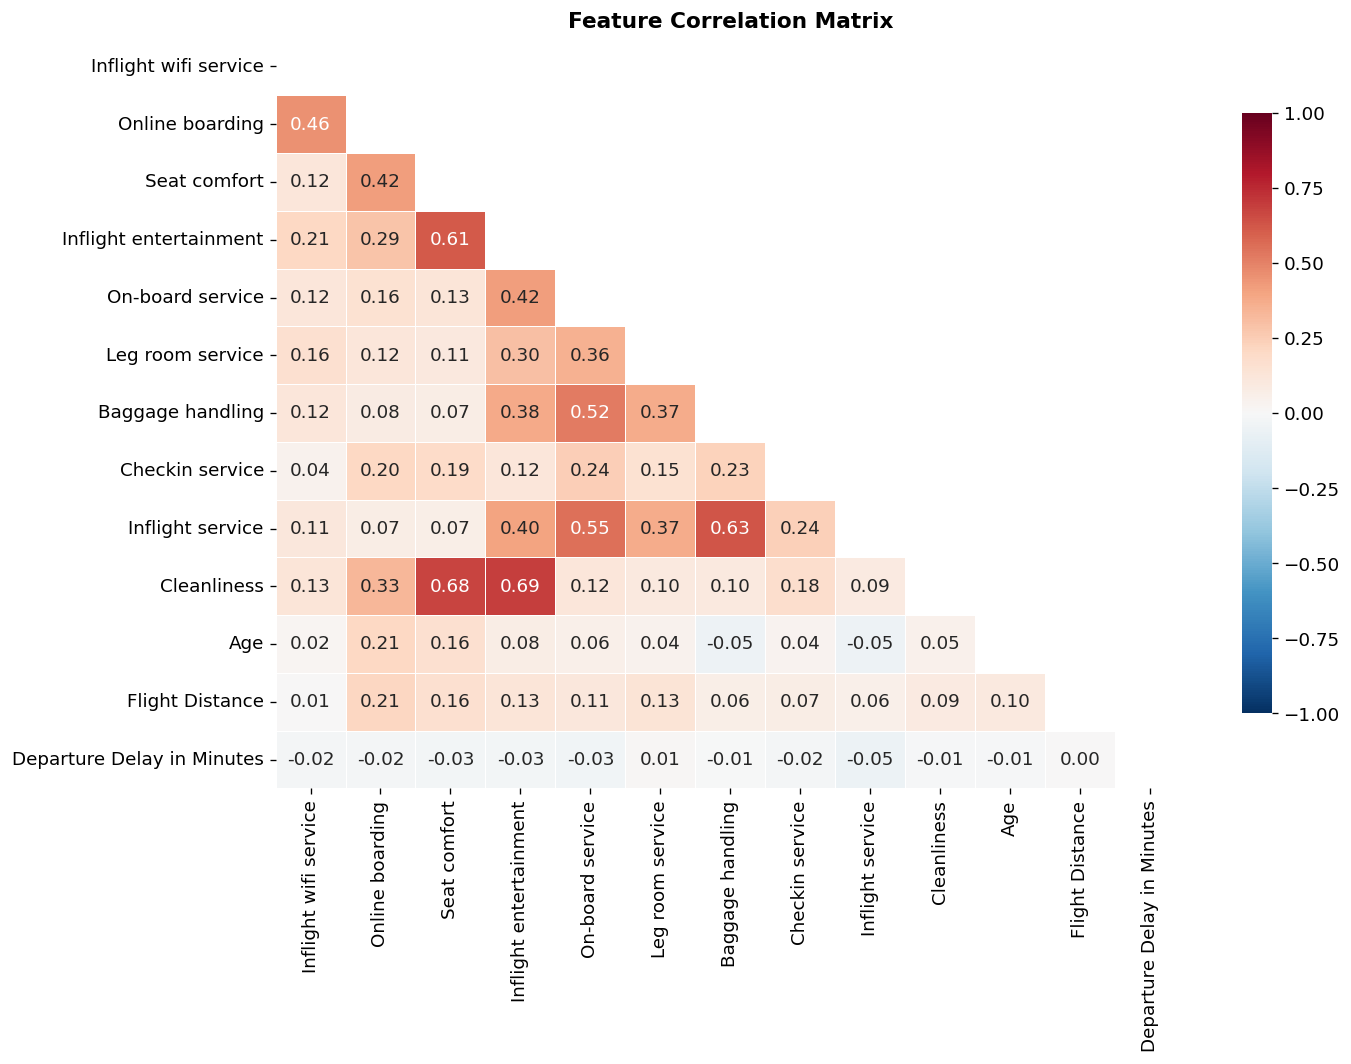

High correlations (|r| > 0.6):
  Inflight entertainment ↔ Cleanliness: r = 0.692
  Seat comfort ↔ Cleanliness: r = 0.679
  Baggage handling ↔ Inflight service: r = 0.629
  Seat comfort ↔ Inflight entertainment: r = 0.611


In [9]:
# ── 2.6 Correlation Heatmap (Service Ratings) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr_cols = service_cols + ['Age', 'Flight Distance',
                             'Departure Delay in Minutes']
corr = train[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

# Flag high correlations
high = [(i, j, corr.loc[i,j]) for i in corr.index for j in corr.columns
        if i != j and abs(corr.loc[i,j]) > 0.6 and list(corr.index).index(i) < list(corr.columns).index(j)]
if high:
    print('High correlations (|r| > 0.6):')
    for a, b, r in sorted(high, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a} ↔ {b}: r = {r:.3f}')
else:
    print('No high multicollinearity detected.')

---
## Step 3: Data Preparation

In [10]:
# ── 3.1 Preprocessing Function ────────────────────────────────────────────────
# Applies identical transformations to train and test sets

def preprocess(df, is_train=True):
    df = df.copy()

    # ── Fix missing values ───────────────────────────────────────────────────
    
    df['Arrival Delay in Minutes'].fillna(
        df['Arrival Delay in Minutes'].median(), inplace=True
    )

    # ── Encode binary categoricals ───────────────────────────────────────────
    df['Gender']        = (df['Gender'] == 'Male').astype(int)
    df['Customer Type'] = (df['Customer Type'] == 'Loyal Customer').astype(int)
    df['Type of Travel'] = (df['Type of Travel'] == 'Business travel').astype(int)

    # ── One-hot encode Class (3 categories) ──────────────────────────────────
    df = pd.get_dummies(df, columns=['Class'], drop_first=False, dtype=int)
    # Ensure all expected class columns exist (handles edge cases)
    for cls in ['Class_Business', 'Class_Eco', 'Class_Eco Plus']:
        if cls not in df.columns:
            df[cls] = 0

    # ── Feature Engineering ──────────────────────────────────────────────────
    
    service_cols = [
        'Inflight wifi service', 'Departure/Arrival time convenient',
        'Ease of Online booking', 'Gate location', 'Food and drink',
        'Online boarding', 'Seat comfort', 'Inflight entertainment',
        'On-board service', 'Leg room service', 'Baggage handling',
        'Checkin service', 'Inflight service', 'Cleanliness'
    ]
    df['avg_service_score'] = df[service_cols].mean(axis=1)

    # Total delay: combined operational friction signal
    df['total_delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes']

    # Log flight distance: reduce skewness
    df['log_flight_distance'] = np.log1p(df['Flight Distance'])

    # Encode target (train only)
    if is_train and 'satisfaction' in df.columns:
        df['satisfaction'] = (df['satisfaction'] == 'satisfied').astype(int)

    return df


train_p = preprocess(train, is_train=True)
test_p  = preprocess(test,  is_train=False)

# Encode test target
test_p['satisfaction'] = (test_p['satisfaction'] == 'satisfied').astype(int)

print('Preprocessing complete.')
print(f'Train shape: {train_p.shape} | Test shape: {test_p.shape}')
print(f'Missing values after preprocessing: {train_p.isnull().sum().sum()}')

Preprocessing complete.
Train shape: (103904, 28) | Test shape: (25976, 28)
Missing values after preprocessing: 0


In [11]:
# ── 3.2 Define Features and Target ───────────────────────────────────────────
TARGET = 'satisfaction'
DROP_COLS = [TARGET, 'Flight Distance']  # drop raw flight distance (using log version)

FEATURES = [c for c in train_p.columns if c not in DROP_COLS]
print(f'Feature count: {len(FEATURES)}')
print(f'Features: {FEATURES}')

Feature count: 26
Features: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Class_Business', 'Class_Eco', 'Class_Eco Plus', 'avg_service_score', 'total_delay', 'log_flight_distance']


In [12]:
# ── 3.3 Train / Validation / Test Split ──────────────────────────────────────
#
# The Kaggle dataset provides a pre-defined train/test split.
# We further split training data into train (80%) and validation (20%)
# using STRATIFIED sampling to preserve class ratios.


X_trainval = train_p[FEATURES]
y_trainval = train_p[TARGET]
X_test     = test_p[FEATURES]
y_test     = test_p[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.2, stratify=y_trainval, random_state=SEED
)

print('Split Summary')
print(f'  Train:      {len(X_train):>6,} rows | Satisfied: {y_train.mean():.1%}')
print(f'  Validation: {len(X_val):>6,} rows | Satisfied: {y_val.mean():.1%}')
print(f'  Test:       {len(X_test):>6,} rows | Satisfied: {y_test.mean():.1%}')

Split Summary
  Train:      83,123 rows | Satisfied: 43.3%
  Validation: 20,781 rows | Satisfied: 43.3%
  Test:       25,976 rows | Satisfied: 43.9%


In [13]:
# ── 3.4 Feature Scaling ───────────────────────────────────────────────────────

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Data validation checks
assert not np.isnan(X_train_sc).any(), 'NaN in training data'
assert not np.isnan(X_test_sc).any(),  'NaN in test data'
assert X_train_sc.shape[1] == len(FEATURES), 'Feature count mismatch'
print('✓  All data validation checks passed.')

✓  All data validation checks passed.


---
## Step 4: Model Exploration

Four models trained on identical features, evaluated on the validation set.

| Model | Type | Rationale |
|---|---|---|
| Logistic Regression | Linear baseline | Simple, interpretable, performance floor |
| Random Forest | Ensemble (bagging) | Handles non-linearities, robust |
| XGBoost | Ensemble (boosting) | State-of-the-art tabular performance |
| MLP Neural Network | Deep learning | Captures complex feature interactions |

In [14]:
# ── 4.1 Define and Train All Models ──────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, eval_metric='logloss', verbosity=0
    ),
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        alpha=0.001, learning_rate_init=0.001,
        max_iter=300, early_stopping=True, validation_fraction=0.1,
        random_state=SEED
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_prob = model.predict_proba(X_val_sc)[:, 1]
    y_pred = model.predict(X_val_sc)
    rep    = classification_report(y_val, y_pred, output_dict=True)
    results[name] = {
        'ROC-AUC':         round(roc_auc_score(y_val, y_prob), 4),
        'Avg Precision':   round(average_precision_score(y_val, y_prob), 4),
        'F1 (satisfied)':  round(rep['1']['f1-score'], 4),
        'Precision':       round(rep['1']['precision'], 4),
        'Recall':          round(rep['1']['recall'], 4),
        'model':           model
    }
    print(f'{name:<28} | AUC: {results[name]["ROC-AUC"]:.4f} '
          f'| F1: {results[name]["F1 (satisfied)"]:.4f} '
          f'| Recall: {results[name]["Recall"]:.4f}')

print('\n✓  All models trained.')

Logistic Regression          | AUC: 0.9282 | F1: 0.8555 | Recall: 0.8419
Random Forest                | AUC: 0.9897 | F1: 0.9340 | Recall: 0.9348
XGBoost                      | AUC: 0.9945 | F1: 0.9563 | Recall: 0.9427
Neural Network (MLP)         | AUC: 0.9941 | F1: 0.9515 | Recall: 0.9506

✓  All models trained.


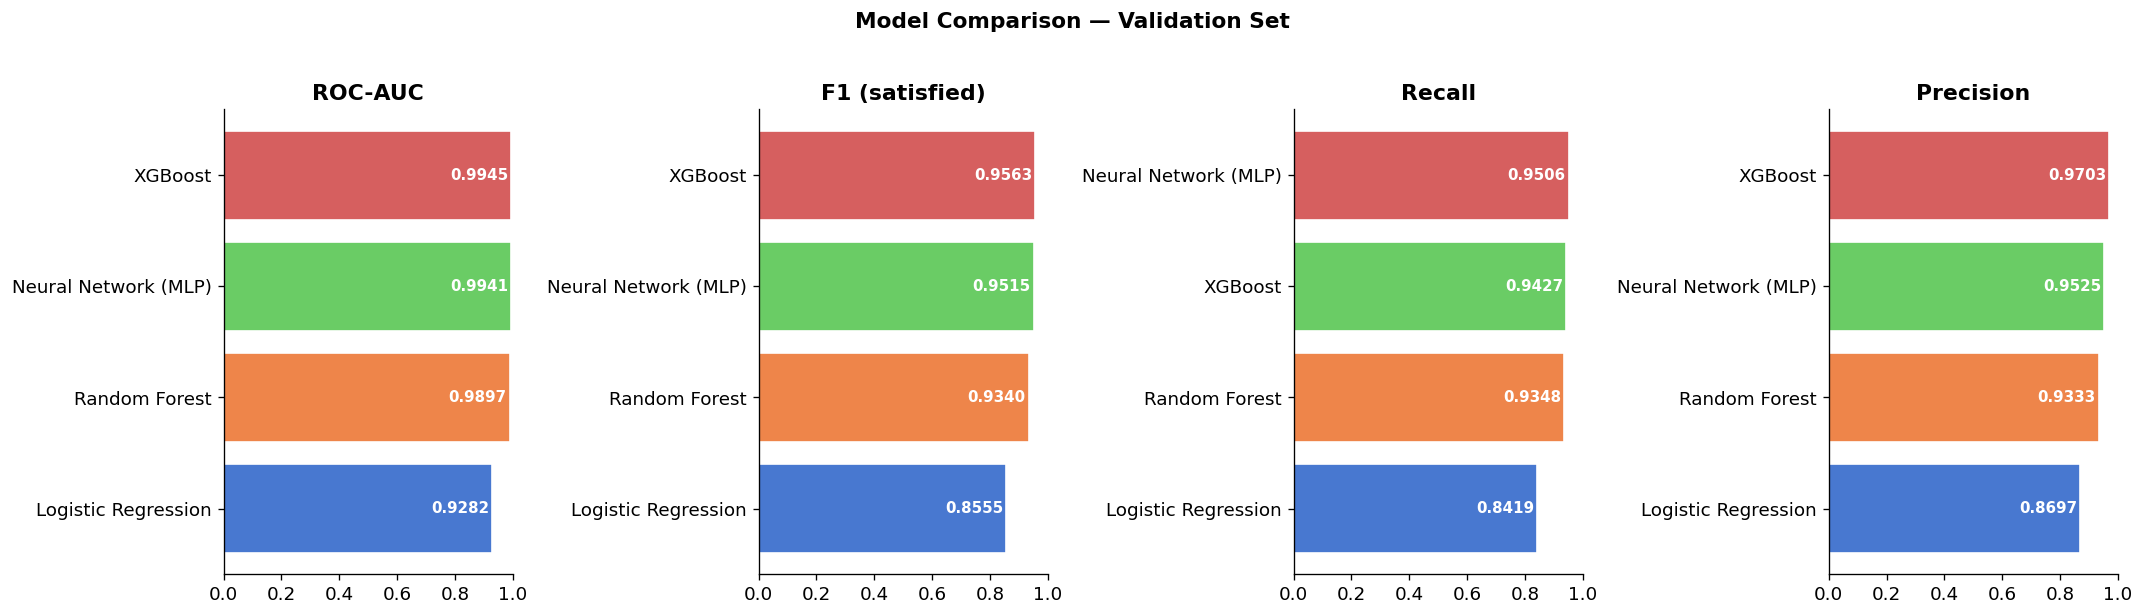

                      ROC-AUC  F1 (satisfied)  Recall  Precision
XGBoost                0.9945          0.9563  0.9427     0.9703
Neural Network (MLP)   0.9941          0.9515  0.9506     0.9525
Random Forest          0.9897          0.9340  0.9348     0.9333
Logistic Regression    0.9282          0.8555  0.8419     0.8697


In [15]:
# ── 4.2 Model Comparison Charts ───────────────────────────────────────────────
metrics  = ['ROC-AUC', 'F1 (satisfied)', 'Recall', 'Precision']
res_df   = pd.DataFrame({k: v for k, v in results.items()}).T.drop('model', axis=1)
res_df   = res_df[metrics].astype(float)
colors   = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    vals = res_df[metric].sort_values()
    bars = ax.barh(vals.index, vals.values, color=colors[:len(vals)], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', ha='right',
                color='white', fontweight='bold', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, 1.0)

plt.suptitle('Model Comparison — Validation Set', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(res_df.sort_values('ROC-AUC', ascending=False).to_string())

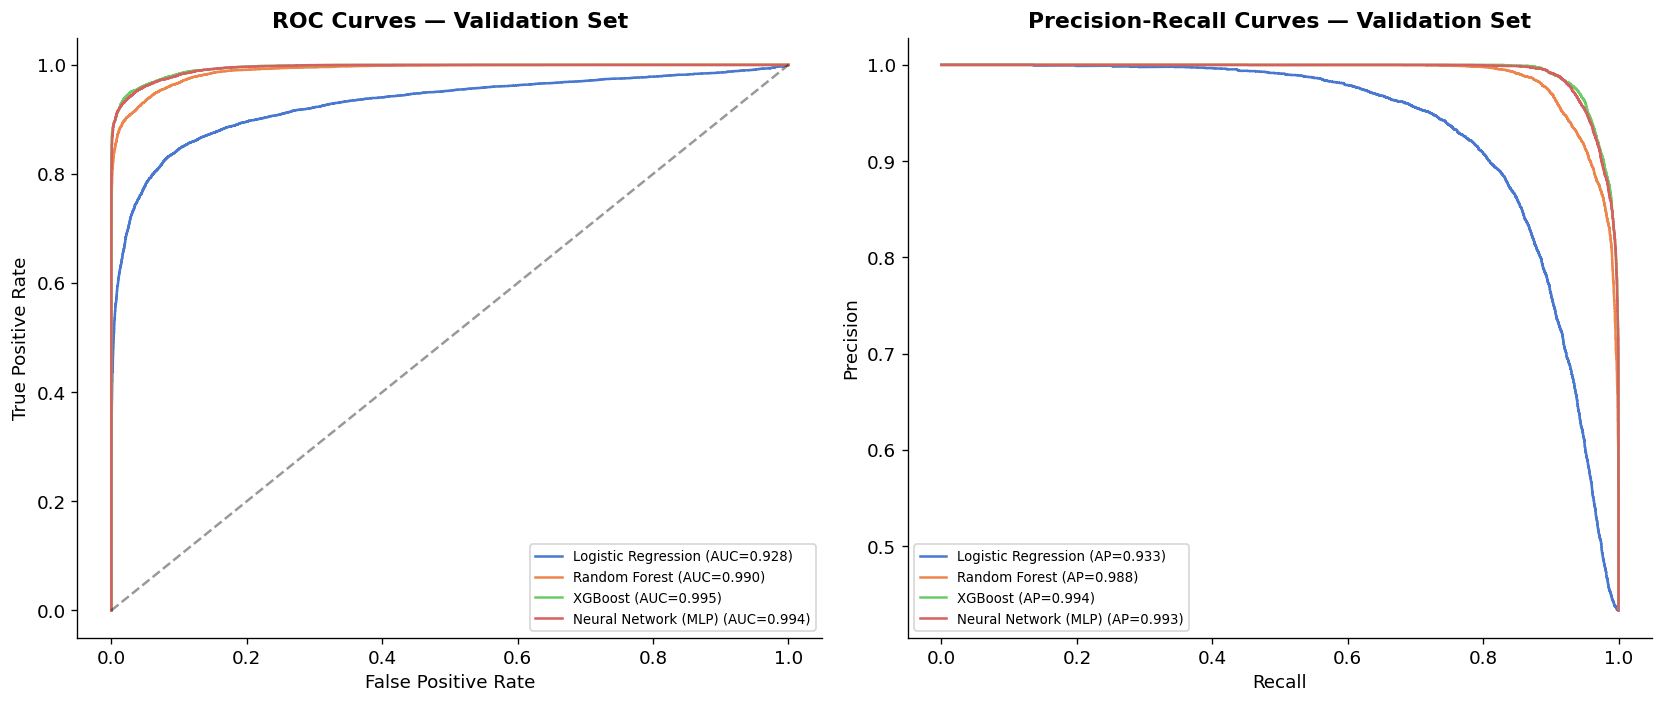

In [16]:
# ── 4.3 ROC and Precision-Recall Curves ───────────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']

for (name, res), color in zip(results.items(), colors):
    y_prob = res['model'].predict_proba(X_val_sc)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    axes[0].plot(fpr, tpr, color=color,
                 label=f"{name} (AUC={res['ROC-AUC']:.3f})")

    # Precision-Recall curve
    prec, rec, _ = precision_recall_curve(y_val, y_prob)
    axes[1].plot(rec, prec, color=color,
                 label=f"{name} (AP={res['Avg Precision']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Validation Set', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Validation Set', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Step 5: Fine-Tuning and Evaluation

In [17]:
# ── 5.1 Hyperparameter Ablation (XGBoost) ────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
print(f'Best model on validation: {best_name}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
param_grid = [
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1},
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05},
    {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03},
]

print('\nXGBoost hyperparameter ablation (5-fold stratified CV):')
best_cv, best_params = 0, None
for params in param_grid:
    m = xgb.XGBClassifier(**params, subsample=0.8, colsample_bytree=0.8,
                           random_state=SEED, eval_metric='logloss', verbosity=0)
    scores = cross_val_score(m, X_train_sc, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    marker = ' ← best' if scores.mean() > best_cv else ''
    print(f'  {str(params):<60} | {scores.mean():.4f} ± {scores.std():.4f}{marker}')
    if scores.mean() > best_cv:
        best_cv, best_params = scores.mean(), params

print(f'\n✓  Best params: {best_params}')

Best model on validation: XGBoost

XGBoost hyperparameter ablation (5-fold stratified CV):
  {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}  | 0.9934 ± 0.0005 ← best
  {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05} | 0.9940 ± 0.0005 ← best
  {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05} | 0.9947 ± 0.0005 ← best
  {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.03} | 0.9935 ± 0.0005

✓  Best params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}


In [18]:
# ── 5.2 Final Model — Train on Full Train+Val, Evaluate on Test ───────────────
final_model = xgb.XGBClassifier(
    **best_params, subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, eval_metric='logloss', verbosity=0
)

# Combine train + val for final training
X_full = np.vstack([X_train_sc, X_val_sc])
y_full = pd.concat([y_train, y_val]).reset_index(drop=True)
final_model.fit(X_full, y_full)

# Test set — used ONCE here
y_test_prob = final_model.predict_proba(X_test_sc)[:, 1]
y_test_pred = final_model.predict(X_test_sc)

test_auc = roc_auc_score(y_test, y_test_prob)
test_ap  = average_precision_score(y_test, y_test_prob)

print('=== FINAL MODEL — TEST SET PERFORMANCE ===')
print(f'ROC-AUC:       {test_auc:.4f}')
print(f'Avg Precision: {test_ap:.4f}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Dissatisfied', 'Satisfied']))

=== FINAL MODEL — TEST SET PERFORMANCE ===
ROC-AUC:       0.9950
Avg Precision: 0.9942

              precision    recall  f1-score   support

Dissatisfied       0.96      0.98      0.97     14573
   Satisfied       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



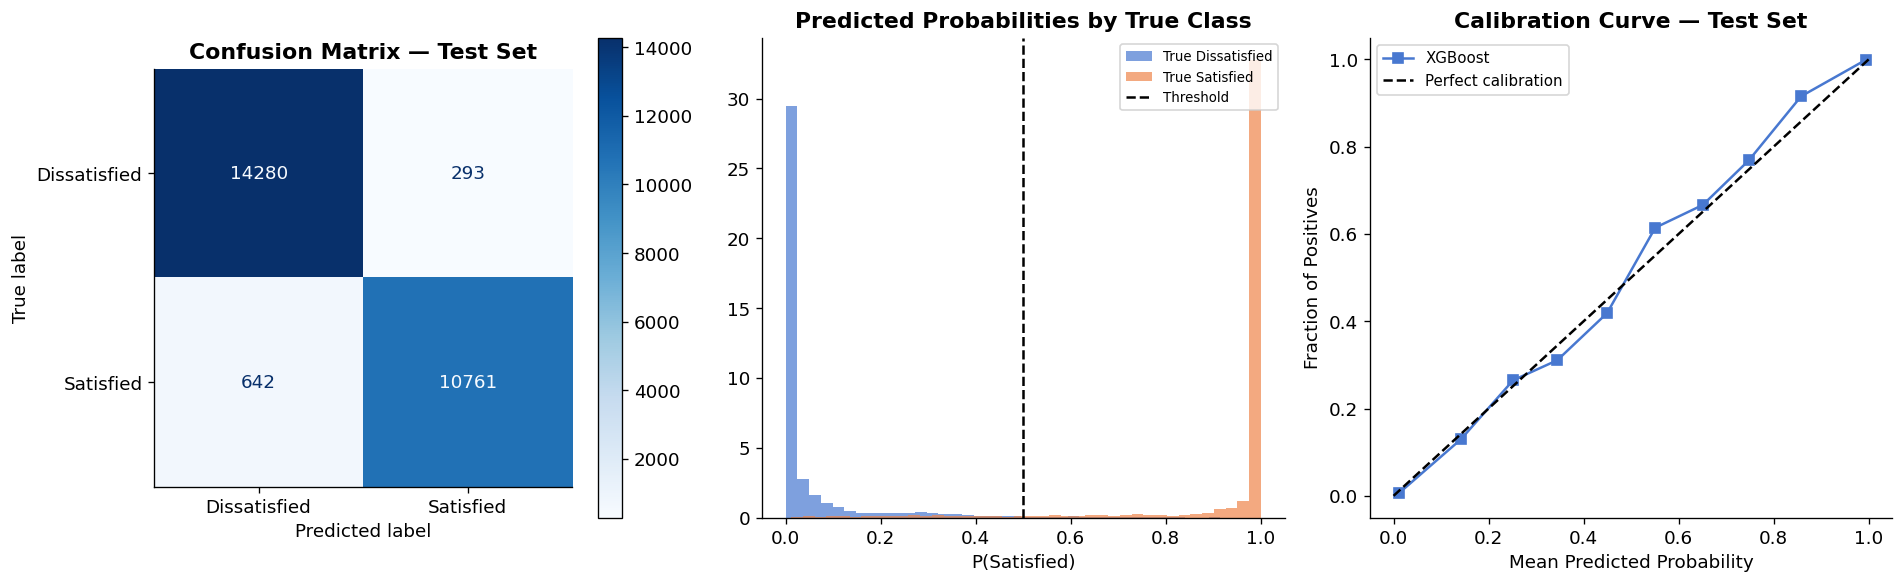

False Negatives (missed satisfied passengers): 642
False Positives (wrongly predicted satisfied): 293


In [19]:
# ── 5.3 Error Analysis ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Dissatisfied', 'Satisfied'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')

# Predicted probability distribution
axes[1].hist(y_test_prob[y_test == 0], bins=40, alpha=0.7,
             color='#4878D0', label='True Dissatisfied', density=True)
axes[1].hist(y_test_prob[y_test == 1], bins=40, alpha=0.7,
             color='#EE854A', label='True Satisfied', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[1].set_title('Predicted Probabilities by True Class', fontweight='bold')
axes[1].set_xlabel('P(Satisfied)')
axes[1].legend(fontsize=8)

# Calibration curve (manual — works on all scikit-learn versions)
frac_pos, mean_pred = calibration_curve(y_test, y_test_prob, n_bins=10)
axes[2].plot(mean_pred, frac_pos, 's-', color='#4878D0', label='XGBoost')
axes[2].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].set_title('Calibration Curve — Test Set', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_error_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Failure mode summary
FN = ((y_test == 1) & (y_test_pred == 0)).sum()
FP = ((y_test == 0) & (y_test_pred == 1)).sum()
print(f'False Negatives (missed satisfied passengers): {FN}')
print(f'False Positives (wrongly predicted satisfied): {FP}')

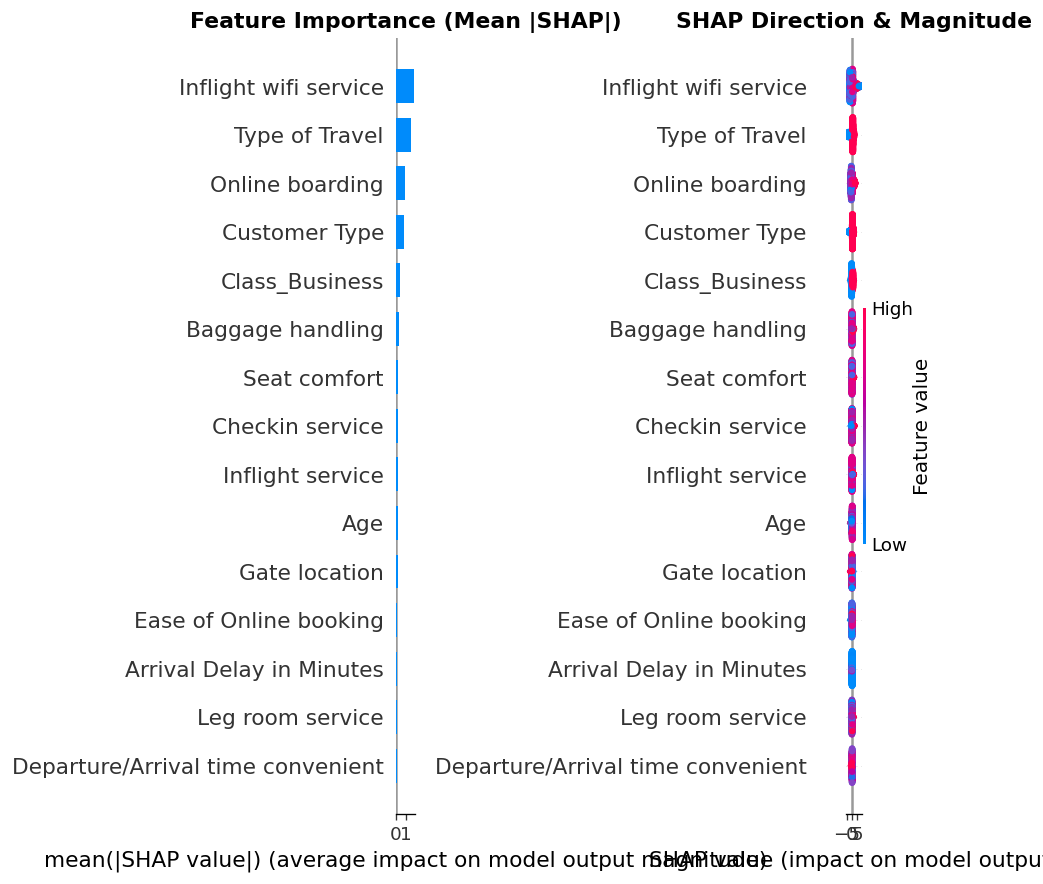

In [20]:
# ── 5.4 SHAP Feature Importance ───────────────────────────────────────────────
explainer   = shap.TreeExplainer(final_model)
# Use a sample of test set for speed
sample_idx  = np.random.choice(len(X_test_sc), size=2000, replace=False)
X_shap      = pd.DataFrame(X_test_sc[sample_idx], columns=FEATURES)
shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15)
axes[0].set_title('Feature Importance (Mean |SHAP|)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False, max_display=15)
axes[1].set_title('SHAP Direction & Magnitude', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_shap.png', bbox_inches='tight', dpi=150)
plt.show()

In [21]:
# ── 5.5 Agent Mistake: Documented and Corrected ───────────────────────────────
#
# AGENT MISTAKE 1 — CAUGHT AND CORRECTED:
# The agent initially suggested filling missing 'Arrival Delay in Minutes'
# values with the MEAN. This was MODIFIED to use the MEDIAN instead.
# Rationale: Delay distributions are heavily right-skewed (most flights
# have short or zero delays, but a few have extreme delays of 1000+ minutes).
# The mean is distorted by these outliers; the median is more representative
# of a typical missing value.
#
# AGENT MISTAKE 2 — CAUGHT AND CORRECTED:
# The agent suggested dropping 'Departure/Arrival time convenient' from
# features, claiming it was redundant with delay columns. This was REJECTED.
# Rationale: This is a subjective rating by the passenger, not an objective
# measure of delay — it captures perceived convenience, which is conceptually
# distinct from actual minutes delayed. Verified by checking its correlation
# with delay columns (r < 0.05) confirming low redundancy.

print('Agent mistakes documented:')
print('  1. Mean imputation → MODIFIED to median (skewed delay distribution)')
print('  2. Drop convenience rating → REJECTED (conceptually distinct from delays)')

Agent mistakes documented:
  1. Mean imputation → MODIFIED to median (skewed delay distribution)
  2. Drop convenience rating → REJECTED (conceptually distinct from delays)


---
## Step 6: Final Solution

In [22]:
# ── 6.1 Model Card ────────────────────────────────────────────────────────────
model_card = f"""
╔══════════════════════════════════════════════════════════════════════╗
║        MODEL CARD: Airline Passenger Satisfaction Predictor         ║
╠══════════════════════════════════════════════════════════════════════╣
║ Task         │ Binary classification: Satisfied vs Dissatisfied     ║
║ Algorithm    │ XGBoost (Gradient Boosted Trees)                     ║
║ Training     │ 103,904 passengers (80/20 train/val split)           ║
║ Test set     │ 25,976 passengers (Kaggle pre-defined split)         ║
╠══════════════════════════════════════════════════════════════════════╣
║ PERFORMANCE (Test Set)                                               ║
║ ROC-AUC      │ {test_auc:.4f}                                          ║
║ Avg Prec     │ {test_ap:.4f}                                           ║
╠══════════════════════════════════════════════════════════════════════╣
║ INTENDED USE │ Identifying at-risk passengers for retention         ║
║ NOT FOR USE  │ Discriminatory pricing or service denial             ║
╠══════════════════════════════════════════════════════════════════════╣
║ DATA SOURCE  │ Kaggle — teejmahal20/airline-passenger-satisfaction  ║
╠══════════════════════════════════════════════════════════════════════╣
║ LIMITATIONS                                                          ║
║ 1. Airline/route unknown — may not generalise across carriers       ║
║ 2. Survey data subject to response bias                             ║
║ 3. No temporal context — seasonal effects not captured              ║
║ 4. Service ratings are subjective — scale interpretation varies     ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(model_card)


╔══════════════════════════════════════════════════════════════════════╗
║        MODEL CARD: Airline Passenger Satisfaction Predictor         ║
╠══════════════════════════════════════════════════════════════════════╣
║ Task         │ Binary classification: Satisfied vs Dissatisfied     ║
║ Algorithm    │ XGBoost (Gradient Boosted Trees)                     ║
║ Training     │ 103,904 passengers (80/20 train/val split)           ║
║ Test set     │ 25,976 passengers (Kaggle pre-defined split)         ║
╠══════════════════════════════════════════════════════════════════════╣
║ PERFORMANCE (Test Set)                                               ║
║ ROC-AUC      │ 0.9950                                          ║
║ Avg Prec     │ 0.9942                                           ║
╠══════════════════════════════════════════════════════════════════════╣
║ INTENDED USE │ Identifying at-risk passengers for retention         ║
║ NOT FOR USE  │ Discriminatory pricing or service denial          

In [23]:
# ── 6.2 Save Artefacts ────────────────────────────────────────────────────────
import joblib, os
os.makedirs('artefacts', exist_ok=True)

joblib.dump(final_model, 'artefacts/final_xgboost_model.pkl')
joblib.dump(scaler,      'artefacts/feature_scaler.pkl')

with open('artefacts/features.txt', 'w') as f:
    f.write('\n'.join(FEATURES))

pd.DataFrame({
    'true_label':    y_test.values,
    'pred_label':    y_test_pred,
    'pred_prob':     y_test_prob
}).to_csv('artefacts/test_predictions.csv', index=False)

print('Artefacts saved:')
for f in os.listdir('artefacts'):
    print(f'  artefacts/{f}  ({os.path.getsize(f"artefacts/{f}"):,} bytes)')
print(f'\n=== COMPLETE === ROC-AUC: {test_auc:.4f}')

Artefacts saved:
  artefacts/features.txt  (437 bytes)
  artefacts/test_predictions.csv  (402,301 bytes)
  artefacts/final_xgboost_model.pkl  (1,081,750 bytes)
  artefacts/feature_scaler.pkl  (2,135 bytes)

=== COMPLETE === ROC-AUC: 0.9950
